In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/pritikannaujiya/twiiter-airline-dataset'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/pritikannaujiya/twiiter-airline-dataset/Tweets.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/pritikannaujiya/twiiter-airline-dataset/Tweets.csv')
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [4]:
df.shape

(14640, 15)

In [5]:
df.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

In [6]:
df = df[['text', 'airline_sentiment']]

In [7]:
df.head()

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [8]:
df.isnull().sum()

text                 0
airline_sentiment    0
dtype: int64

In [9]:
df['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

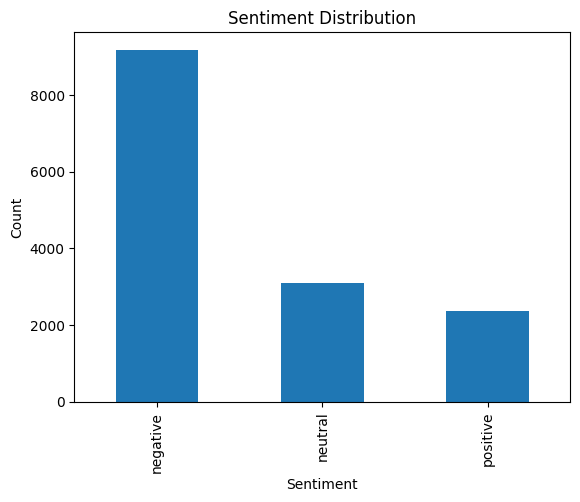

In [10]:
import matplotlib.pyplot as plt
df['airline_sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [11]:
df.head()

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [12]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['sentiment']=le.fit_transform(df['airline_sentiment'])
df.drop('airline_sentiment', axis=1, inplace=True)

In [13]:
df.head()

,text,sentiment
0,@VirginAmerica What @dhepburn said.,1
1,@VirginAmerica plus you've added commercials t...,2
2,@VirginAmerica I didn't today... Must mean I n...,1
3,@VirginAmerica it's really aggressive to blast...,0
4,@VirginAmerica and it's a really big bad thing...,0


In [14]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)        # remove links
    text = re.sub(r'@\w+', '', text)           # remove mentions
    text = re.sub(r'#', '', text)              # remove hashtags
    text = re.sub(r'\d+', '', text)            # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation)) #This removes all punctuation marks from text.
    text = text.strip()                        # Removes extra spaces from beginning and end
    return text

df['text'] = df['text'].apply(clean_text)

In [15]:
df.head()

,text,sentiment
0,what said,1
1,plus youve added commercials to the experience...,2
2,i didnt today must mean i need to take another...,1
3,its really aggressive to blast obnoxious enter...,0
4,and its a really big bad thing about it,0


In [16]:
pip install transformers 

Note: you may need to restart the kernel to use updated packages.


In [17]:
from transformers import AutoTokenizer,AutoModel

In [18]:
model_name = "sentence-transformers/all-MiniLM-L6-v2"


In [19]:
tokenizer=AutoTokenizer.from_pretrained(model_name)
sbert=AutoModel.from_pretrained(model_name)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [20]:
encoded = tokenizer(
    list(df['text']),
    add_special_tokens=True,
    max_length=128,
    padding='max_length',
    truncation=True,
    return_attention_mask=True
)

In [25]:
input_ids=encoded['input_ids']

In [29]:
len(input_ids)

14640

In [30]:
input_ids[0]

[101,
 2054,
 2056,
 102,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [31]:
attention_mask=encoded['attention_mask']

In [32]:
len(attention_mask[0])

128

In [33]:
import torch
input_ids = torch.tensor(input_ids)
attention_mask = torch.tensor(attention_mask)

labels = torch.tensor(df['sentiment'].values)
labels

tensor([1, 2, 1,  ..., 1, 0, 1])

## SBERT + BiLSTM + Residual Model

In [34]:
import torch.nn as nn

class SBERT_BiLSTM_Residual(nn.Module):
    def __init__(self, hidden_dim=128, num_classes=3):
        super().__init__()

        self.sbert = sbert

        self.bilstm = nn.LSTM(
            input_size=384,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        # Residual block
        self.fc = nn.Linear(hidden_dim * 2, hidden_dim * 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, attention_mask):

        # SBERT embeddings
        with torch.no_grad():   # freeze SBERT (important)
            outputs = self.sbert(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        x = outputs.last_hidden_state  # (batch, seq_len, 384)

        # BiLSTM
        lstm_out, _ = self.bilstm(x)

        # Better than last step → mean pooling
        out = torch.mean(lstm_out, dim=1)

        # Residual connection
        res = out
        out = self.fc(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = out + res

        return self.classifier(out)

In [35]:
from torch.utils.data import TensorDataset, DataLoader, random_split

dataset = TensorDataset(input_ids, attention_mask, labels)

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)


In [36]:
print(torch.cuda.is_available())
device = torch.device("cpu")

True


## Define loss + optimizer

In [37]:
model =  SBERT_BiLSTM_Residual().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# Training Loop

In [38]:
for epoch in range(3):
    model.train()
    total_loss = 0

    for batch in train_loader:
        input_ids, attention_mask, labels = [x.to(device) for x in batch]

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Training Loss: {total_loss:.4f}")

    model.eval()  
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad(): 
        for batch in val_loader:
            input_ids, attention_mask, labels = [x.to(device) for x in batch]

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_accuracy = correct / total

    print(f"Validation Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}")

Epoch 1, Training Loss: 488.5477
Validation Loss: 47.6473, Accuracy: 0.8019
Epoch 2, Training Loss: 414.3461
Validation Loss: 47.0235, Accuracy: 0.8053
Epoch 3, Training Loss: 395.5146
Validation Loss: 45.4155, Accuracy: 0.8122


In [41]:
  torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": epoch,
        "loss": total_loss
    }, "/kaggle/working/checkpoint.pth")

In [40]:
torch.save(model.state_dict(), "sbert_bilstm_residual_airline.pth")


## Evaluation

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in train_loader:
        input_ids, attention_mask, labels = [x.to(device) for x in batch]

        outputs = model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

train_accuracy = accuracy_score(all_labels, all_preds)
train_precision = precision_score(all_labels, all_preds, average="weighted")
train_recall = recall_score(all_labels, all_preds, average="weighted")
train_f1 = f1_score(all_labels, all_preds, average="weighted")

print("Training Accuracy:", train_accuracy)
print("Training Precision:", train_precision)
print("Training Recall:", train_recall)
print("Training F1 Score:", train_f1)


Training Accuracy: 0.8252125075895568
Training Precision: 0.8240092768202631
Training Recall: 0.8252125075895568
Training F1 Score: 0.8243285016183076


# Validation Accuracy

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids, attention_mask, labels = [x.to(device) for x in batch]

        outputs = model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

val_accuracy = accuracy_score(all_labels, all_preds)
val_precision = precision_score(all_labels, all_preds, average="weighted")
val_recall = recall_score(all_labels, all_preds, average="weighted")
val_f1 = f1_score(all_labels, all_preds, average="weighted")

print("Validation Accuracy:", val_accuracy)
print("Validation Precision:", val_precision)
print("Validation Recall:", val_recall)
print("Validation F1 Score:", val_f1)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))


Validation Accuracy: 0.8121584699453552
Validation Precision: 0.8094576507357
Validation Recall: 0.8121584699453552
Validation F1 Score: 0.810333701208854

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       895
           1       0.69      0.66      0.67       335
           2       0.78      0.71      0.75       234

    accuracy                           0.81      1464
   macro avg       0.78      0.76      0.77      1464
weighted avg       0.81      0.81      0.81      1464



In [46]:
df_test = pd.read_csv("/kaggle/input/datasets/pritikannaujiya/test-dataairline/twitter_airline_sentiment_ml_ready.csv")

In [47]:
df_test.head()

,clean_text,sentiment_label,airline,word_count,avg_word_length,tweet_year
0,plus youve added commercials to the experience...,2,Virgin America,8,6.500000,2015
1,i didnt today must mean i need to take another...,1,Virgin America,11,4.636364,2015
2,its really aggressive to blast obnoxious enter...,0,Virgin America,16,6.562500,2015
3,and its a really big bad thing about it,0,Virgin America,9,4.333333,2015
4,seriously would pay a flight for seats that di...,0,Virgin America,21,5.380952,2015


In [48]:
df_test.shape

(13976, 6)

In [49]:
df_test = df_test[['clean_text', 'sentiment_label']]
df_test.head()

,clean_text,sentiment_label
0,plus youve added commercials to the experience...,2
1,i didnt today must mean i need to take another...,1
2,its really aggressive to blast obnoxious enter...,0
3,and its a really big bad thing about it,0
4,seriously would pay a flight for seats that di...,0


In [50]:
texts = df_test['clean_text'].tolist()
labels = df_test['sentiment_label'].tolist()

In [51]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')

encodings = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

input_ids = encodings["input_ids"]
attention_mask = encodings["attention_mask"]

labels = torch.tensor(labels)

In [52]:
from torch.utils.data import TensorDataset, DataLoader

test_data = TensorDataset(input_ids, attention_mask, labels)
test_loader = DataLoader(test_data, batch_size=16)

In [53]:
import torch

def evaluate(model, test_loader, device):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids, attention_mask, labels = [x.to(device) for x in batch]

            outputs = model(input_ids, attention_mask)

            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")

    return accuracy

In [54]:
evaluate(model, test_loader, device)

Test Accuracy: 0.8156


0.8156124785346308

In [55]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [56]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, labels = [x.to(device) for x in batch]

        outputs = model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [57]:
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.8157464452542633
Recall: 0.8156124785346308
F1 Score: 0.815446640771817
